**Data Understanding**

Data Understanding is the first phase in the Data Science Lifecycle (especially in CRISP-DM) and involves exploring and getting familiar with the data. It includes assessing data quality, discovering patterns, detecting outliers, and forming hypotheses.

<img src="image.jpg" width="600">

**Visualise Iris dataset**

In [16]:
# First, we'll import pandas
import pandas as pd

# We'll also import seaborn, and matplotlib for visualization
import seaborn as sns
import matplotlib.pyplot as plt

import warnings 
warnings.filterwarnings("ignore")

In [17]:
# Next, we'll load the Iris flower dataset
iris = pd.read_csv("C:/MAFAS/APU/CT046-3-M-AML/CT046 - LABS/Python LAB MATERIALS/Lab 2 - Data Understanding/Iris.csv") # the iris dataset is now a Pandas DataFrame

# Let's see what's in the iris data - Jupyter notebooks print the first 5 records by default
iris.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa


In [18]:
iris.tail() # Let's see the last 5 records in the dataset

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
146,147,6.3,2.5,5.0,1.9,virginica
147,148,6.5,3.0,5.2,2.0,virginica
148,149,6.2,3.4,5.4,2.3,virginica
149,150,5.9,3.0,5.1,1.8,virginica
150,1,NaN,NaN,NaN,NaN,NaN


In [19]:
# Let's see how many records we have of each species
iris["Species"].value_counts()


Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

<Axes: xlabel='SepalLengthCm', ylabel='SepalWidthCm'>

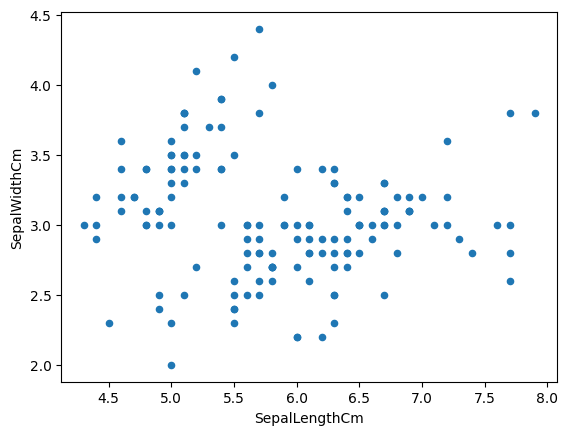

In [20]:
# The first way we can plot things is using the .plot extension from Pandas dataframe to make a scatterplot

iris.plot(kind = "scatter", x = "SepalLengthCm", y = "SepalWidthCm")

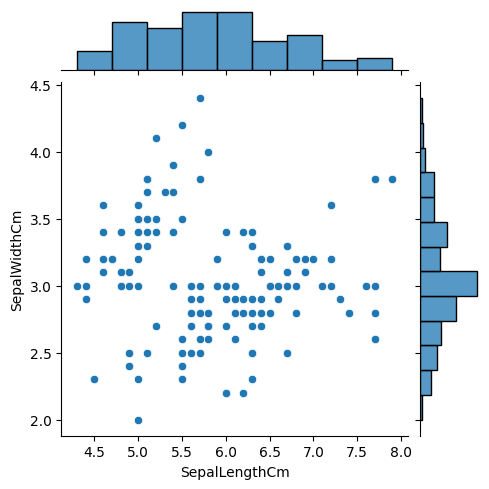

In [21]:
# We can also use the seaborn library to make a jointplot to show bivariate scatterplots and univariate histograms in the same figure

sns.jointplot(x = "SepalLengthCm", y = "SepalWidthCm", data = iris, height = 5)

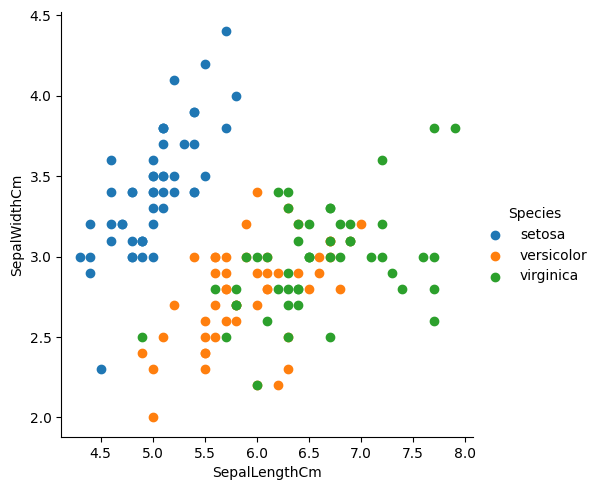

In [22]:
# One piece of information missing in the plots above is what species each plant is
# We'll use seaborn's FacetGrid to color the scatterplot by species

sns.FacetGrid(iris, hue = "Species", height = 5) \
   .map(plt.scatter, "SepalLengthCm", "SepalWidthCm") \
   .add_legend()

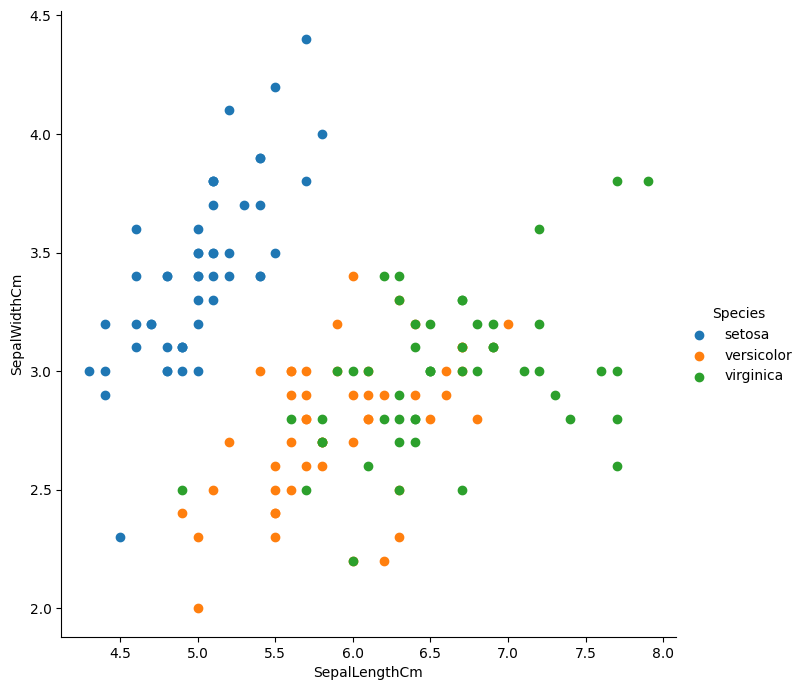

In [23]:
#One piece of information missing in the plots above is what species each plant is
# We'll use seaborn's FacetGrid to color the scatterplot by species

sns.FacetGrid(iris, hue = "Species", height = 7) \
   .map(plt.scatter, "SepalLengthCm", "SepalWidthCm") \
   .add_legend()

<Axes: xlabel='Species', ylabel='PetalLengthCm'>

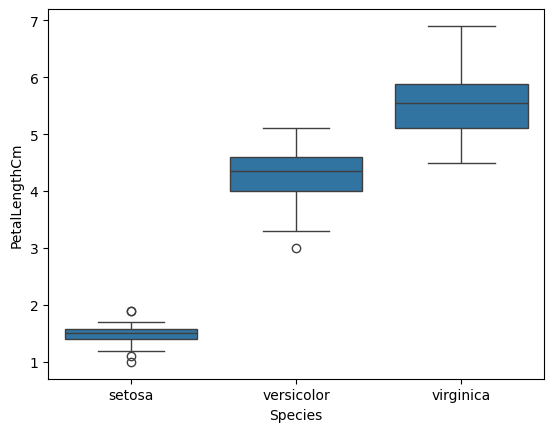

In [24]:
# We can look at an individual feature in Seaborn through a boxplot
sns.boxplot(x = "Species", y = "PetalLengthCm", data = iris)

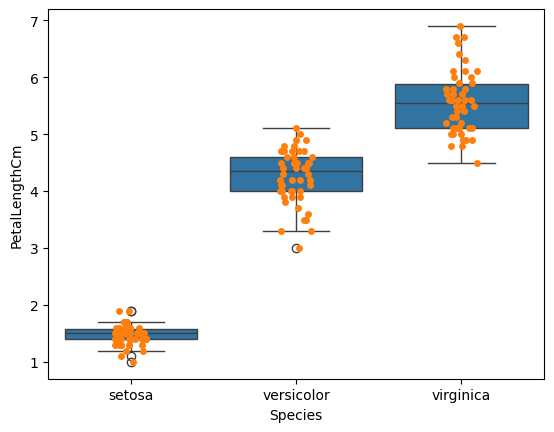

In [25]:
# One way we can extend this plot is adding a layer of individual points on top of it through Seaborn's striplot
# We'll use jitter=True so that all the points don't fall in single vertical lines above the species
# Saving the resulting axes as ax each time causes the resulting plot to be shown on top of the previous axes

ax = sns.boxplot(x = "Species", y = "PetalLengthCm", data = iris)
ax = sns.stripplot(x = "Species", y = "PetalLengthCm", data = iris, jitter = True, edgecolor = "gray")

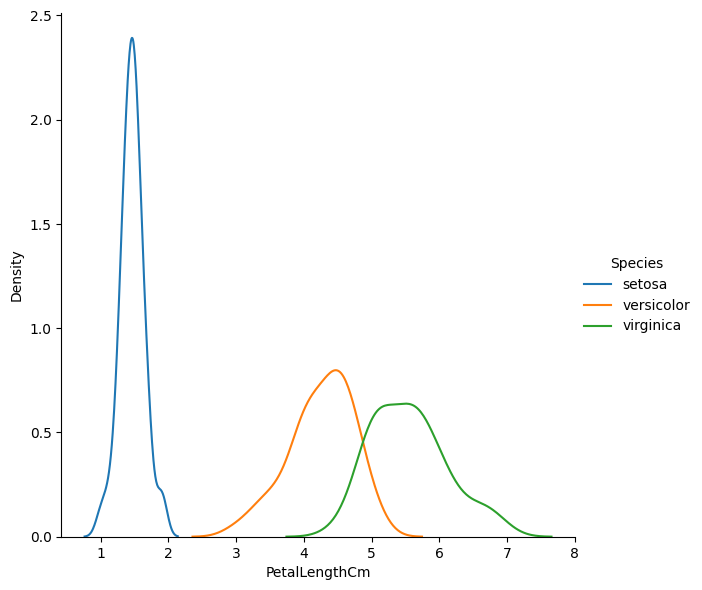

In [26]:
# A seaborn plot useful for looking at univariate relations is the kdeplot, which creates and visualizes a kernel density estimate of the underlying feature

sns.FacetGrid(iris, hue = "Species", height = 6) \
   .map(sns.kdeplot, "PetalLengthCm") \
   .add_legend()

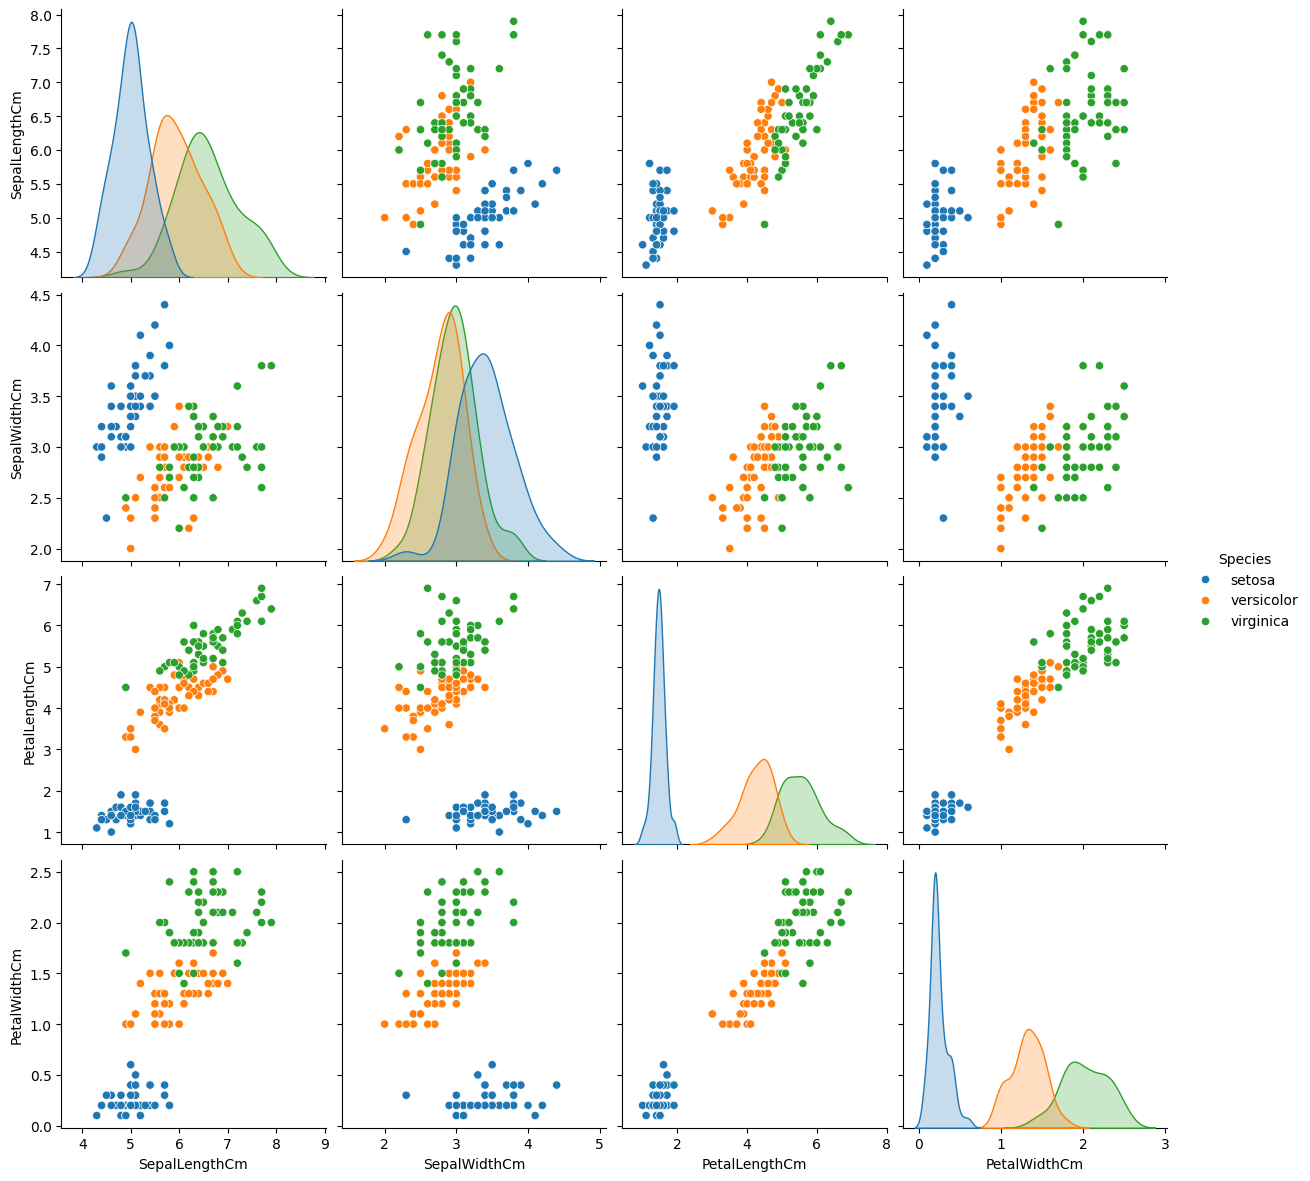

In [27]:
# Another useful seaborn plot is the pairplot, which shows the bivariate relation between each pair of features
# From the pairplot, we'll see that the Iris-setosa species is separataed from the other two across all feature combinations

sns.pairplot(iris.drop("Id", axis = 1), hue = "Species", height = 3, diag_kind = "kde")

array([[<Axes: title={'center': 'PetalLengthCm'}, xlabel='[Species]'>,
        <Axes: title={'center': 'PetalWidthCm'}, xlabel='[Species]'>],
       [<Axes: title={'center': 'SepalLengthCm'}, xlabel='[Species]'>,
        <Axes: title={'center': 'SepalWidthCm'}, xlabel='[Species]'>]],
      dtype=object)

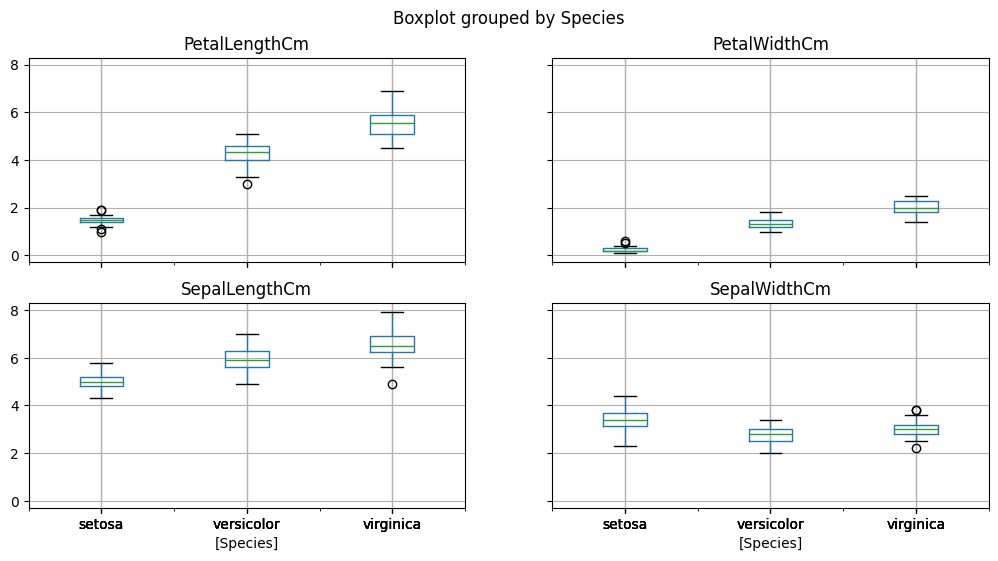

In [28]:
# We can quickly make a boxplot with Pandas on each feature split out by species

iris.drop("Id", axis = 1).boxplot(by = "Species", figsize = (12, 6))

<Axes: >

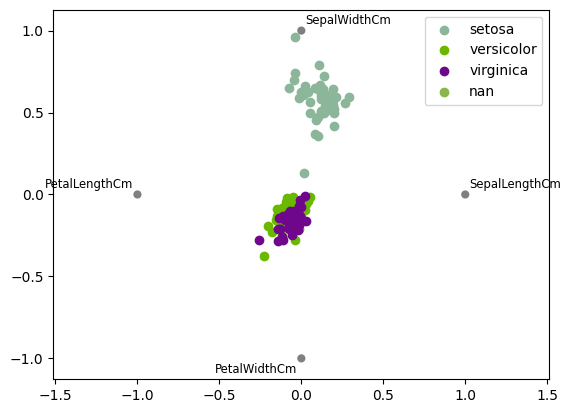

In [29]:
# A final multivariate visualization technique pandas has is radviz
# Which puts each feature as a point on a 2D plane, and then simulates having each sample attached to those points through a spring weighted by the relative value for that feature

from pandas.plotting import radviz
radviz(iris.drop("Id", axis = 1), "Species")

**🧠 Lab Exercise:**

Use "telecom_churn" dataset and perform Data Understading via suitable visualisations.